# 🏫 GAN + ANN Campus Security Incident Analysis

**Project:** Synthetic Data Augmentation and Incident Risk Prediction  
**Dataset:** Campus security incidents (500 real records)  
**Goal:** Use CTGAN to generate synthetic incident data, then train an ANN to predict incident severity.

---

## Pipeline Overview

```
Raw Data → Preprocessing → CTGAN (Synthetic Data) → Combined Dataset → ANN Classifier → Evaluation
```

**Target variable:** `severity` (0 = Low, 1 = Medium, 2 = High)


## 0. Install Dependencies

Uncomment and run this cell once if packages are not installed.

In [1]:
# !pip install pandas numpy scikit-learn torch matplotlib seaborn sdv

## 1. Load and Explore Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('campus_incidents.csv')

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn types:\n{df_raw.dtypes}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
df_raw.head()

Dataset shape: (500, 6)

Column types:
location         object
event_type       object
time_of_day      object
crowd_size        int64
incident_type    object
severity          int64
dtype: object

Missing values:
location         0
event_type       0
time_of_day      0
crowd_size       0
incident_type    0
severity         0
dtype: int64


,location,event_type,time_of_day,crowd_size,incident_type,severity
0,Lecture Hall,Festival,Night,391,Disturbance,2
1,Cafeteria,Concert,Night,459,Medical,2
2,Sports Complex,Party,Night,320,Medical,2
3,Cafeteria,Sports Event,Night,236,Disturbance,1
4,Cafeteria,Sports Event,Night,179,Disturbance,1


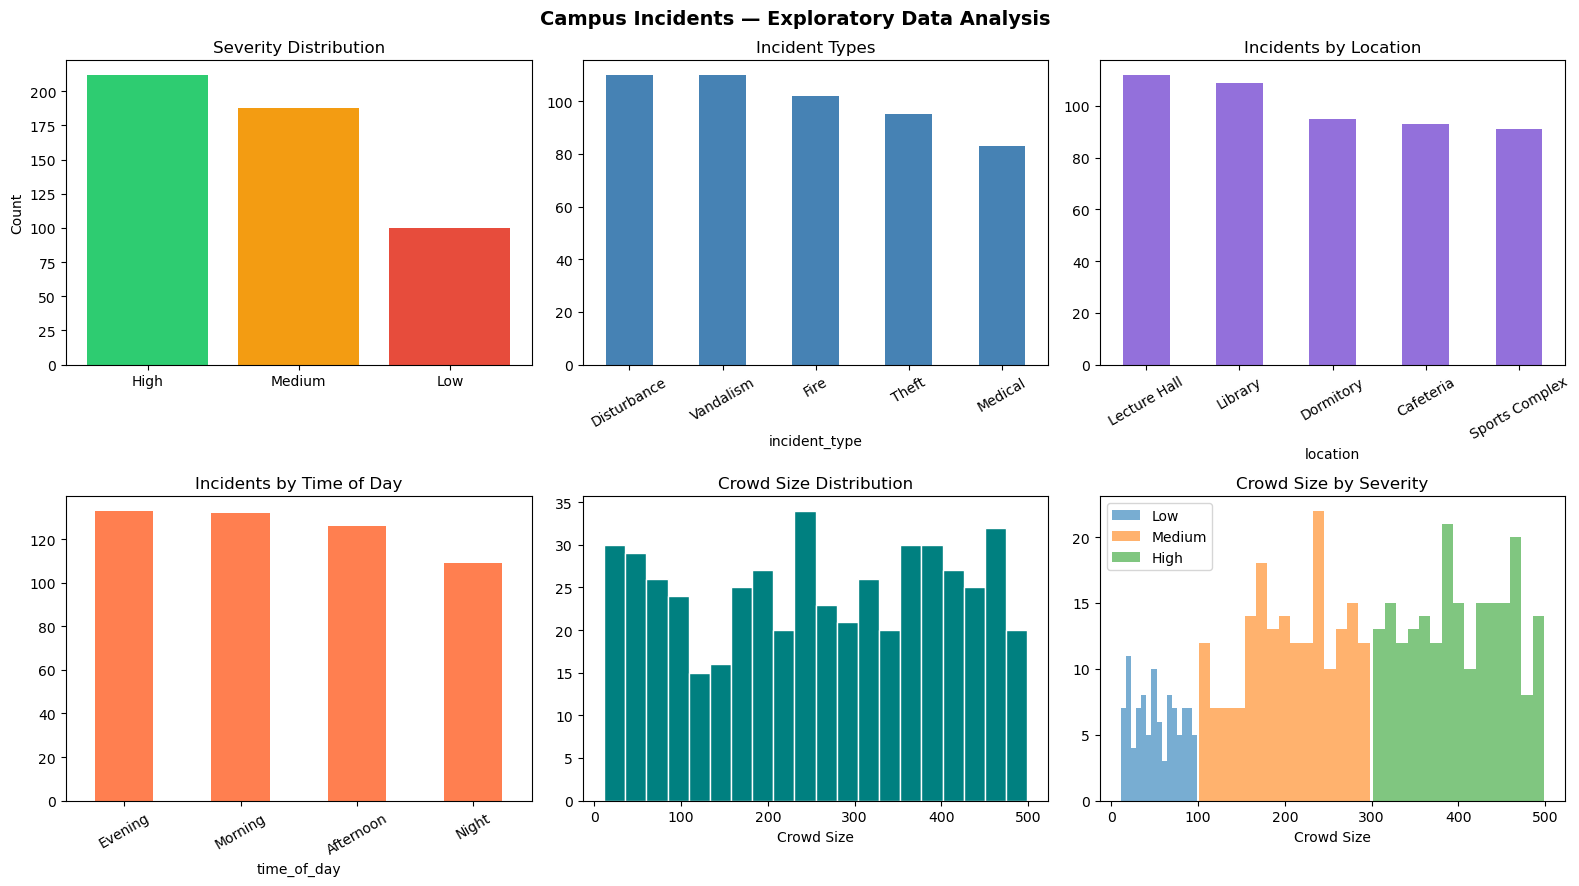

EDA plots saved to eda_plots.png


In [3]:
# --- Exploratory Data Analysis ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Campus Incidents — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Severity distribution
severity_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
counts = df_raw['severity'].map(severity_labels).value_counts()
axes[0, 0].bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0, 0].set_title('Severity Distribution')
axes[0, 0].set_ylabel('Count')

# Incident type
df_raw['incident_type'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Incident Types')
axes[0, 1].tick_params(axis='x', rotation=30)

# Location
df_raw['location'].value_counts().plot(kind='bar', ax=axes[0, 2], color='mediumpurple')
axes[0, 2].set_title('Incidents by Location')
axes[0, 2].tick_params(axis='x', rotation=30)

# Time of day
df_raw['time_of_day'].value_counts().plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Incidents by Time of Day')
axes[1, 0].tick_params(axis='x', rotation=30)

# Crowd size distribution
axes[1, 1].hist(df_raw['crowd_size'], bins=20, color='teal', edgecolor='white')
axes[1, 1].set_title('Crowd Size Distribution')
axes[1, 1].set_xlabel('Crowd Size')

# Crowd size vs severity
for sev, label in severity_labels.items():
    axes[1, 2].hist(df_raw[df_raw['severity'] == sev]['crowd_size'],
                    bins=15, alpha=0.6, label=label)
axes[1, 2].set_title('Crowd Size by Severity')
axes[1, 2].set_xlabel('Crowd Size')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved to eda_plots.png")

## 2. Preprocess Data

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = df_raw.copy()

# Encode categorical columns
categorical_cols = ['location', 'event_type', 'time_of_day', 'incident_type']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Scale continuous feature
scaler = StandardScaler()
df[['crowd_size']] = scaler.fit_transform(df[['crowd_size']])

target = 'severity'

print(f"\nPreprocessed data shape: {df.shape}")
df.head()

location: {'Cafeteria': 0, 'Dormitory': 1, 'Lecture Hall': 2, 'Library': 3, 'Sports Complex': 4}
event_type: {'Concert': 0, 'Festival': 1, 'Party': 2, 'Seminar': 3, 'Sports Event': 4}
time_of_day: {'Afternoon': 0, 'Evening': 1, 'Morning': 2, 'Night': 3}
incident_type: {'Disturbance': 0, 'Fire': 1, 'Medical': 2, 'Theft': 3, 'Vandalism': 4}

Preprocessed data shape: (500, 6)


,location,event_type,time_of_day,crowd_size,incident_type,severity
0,2,1,3,0.922764,0,2
1,0,0,3,1.396063,2,2
2,4,2,3,0.428585,2,2
3,0,4,3,-0.156077,0,1
4,0,4,3,-0.552812,0,1


## 3. Generate Synthetic Data with CTGAN

CTGAN (Conditional Tabular GAN) learns the joint distribution of all columns and generates realistic synthetic rows. We use it to augment the 500-row real dataset with 5,000 synthetic records.

In [6]:
from sdv.metadata import Metadata

# Detect metadata from dataframe (run once, then save)
metadata = Metadata.detect_from_dataframe(df)
metadata.save_to_json('metadata.json')
print("Metadata detected and saved to metadata.json")

Metadata detected and saved to metadata.json


In [7]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import Metadata

# Load saved metadata (avoids re-detection warning)
metadata = Metadata.load_from_json('metadata.json')

# Train CTGAN
ctgan = CTGANSynthesizer(metadata, epochs=100, verbose=True)
ctgan.fit(df)

# Generate synthetic data
N_SYNTHETIC = 5000
synthetic_data = ctgan.sample(num_rows=N_SYNTHETIC)

print(f"\nSynthetic data shape: {synthetic_data.shape}")
synthetic_data.head()

Gen. (+01.00) | Discrim. (+00.08): 100%|███████████████████████████████| 100/100 [00:10<00:00,  9.43it/s]



Synthetic data shape: (5000, 6)


,location,event_type,time_of_day,crowd_size,incident_type,severity
0,2,4,0,-1.046459,3,1
1,2,3,2,0.887618,2,2
2,0,0,2,1.209729,0,1
3,0,0,2,-0.322425,3,0
4,0,2,2,0.409802,3,2


=== Real Data Statistics ===
       location  event_type  time_of_day  crowd_size  incident_type  severity
count   500.000     500.000      500.000     500.000        500.000   500.000
mean      2.020       1.994        1.448       0.000          1.986     1.224
std       1.372       1.408        1.091       1.001          1.469     0.758
min       0.000       0.000        0.000      -1.722          0.000     0.000
25%       1.000       1.000        0.000      -0.842          1.000     1.000
50%       2.000       2.000        1.000       0.011          2.000     1.000
75%       3.000       3.000        2.000       0.888          3.000     2.000
max       4.000       4.000        3.000       1.674          4.000     2.000

=== Synthetic Data Statistics ===
       location  event_type  time_of_day  crowd_size  incident_type  severity
count  5000.000    5000.000     5000.000    5000.000       5000.000  5000.000
mean      2.023       2.060        1.567       0.739          1.944     1.179


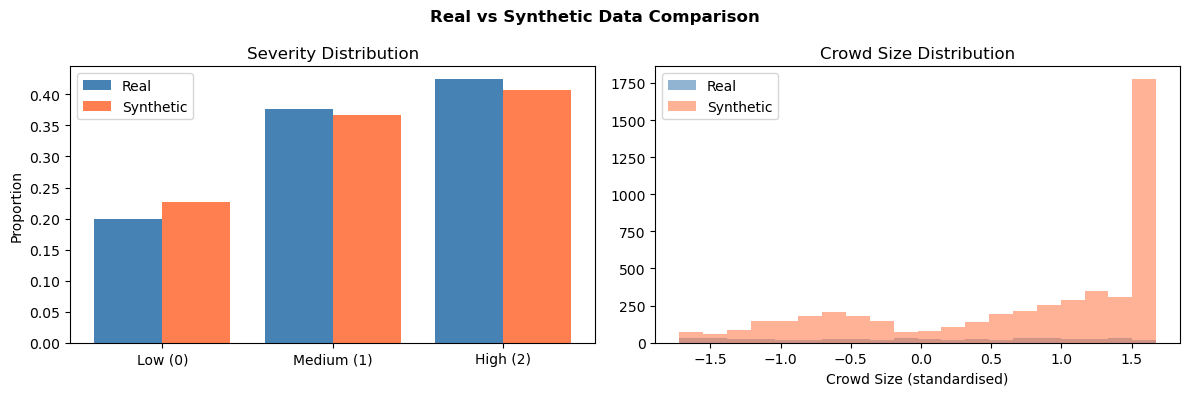

In [8]:
# --- Validate Synthetic Data Quality ---
print("=== Real Data Statistics ===")
print(df.describe().round(3))
print("\n=== Synthetic Data Statistics ===")
print(synthetic_data.describe().round(3))

# Compare severity distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Real vs Synthetic Data Comparison', fontweight='bold')

real_sev = df['severity'].value_counts(normalize=True).sort_index()
syn_sev  = synthetic_data['severity'].value_counts(normalize=True).sort_index()

x = np.arange(len(real_sev))
axes[0].bar(x - 0.2, real_sev.values, 0.4, label='Real', color='steelblue')
axes[0].bar(x + 0.2, syn_sev.values,  0.4, label='Synthetic', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Low (0)', 'Medium (1)', 'High (2)'])
axes[0].set_title('Severity Distribution')
axes[0].set_ylabel('Proportion')
axes[0].legend()

axes[1].hist(df['crowd_size'], bins=20, alpha=0.6, label='Real', color='steelblue')
axes[1].hist(synthetic_data['crowd_size'], bins=20, alpha=0.6, label='Synthetic', color='coral')
axes[1].set_title('Crowd Size Distribution')
axes[1].set_xlabel('Crowd Size (standardised)')
axes[1].legend()

plt.tight_layout()
plt.savefig('synthetic_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Prepare Combined Dataset for ANN

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Combine real + synthetic
combined_df = pd.concat([df, synthetic_data], ignore_index=True)

# Encode any remaining object columns and force numeric
combined_df = pd.get_dummies(combined_df, drop_first=True)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce').fillna(0)

X = combined_df.drop(columns=[target]).values.astype('float32')
y = combined_df[target].values.astype('int64')

# Adjust labels to be 0-indexed if needed
y = y - y.min()
num_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Input features   : {X_train.shape[1]}")
print(f"Number of classes: {num_classes}")
print(f"Class distribution (train): {np.bincount(y_train)}")

Training samples : 4400
Test samples     : 1100
Input features   : 5
Number of classes: 3
Class distribution (train): [ 988 1617 1795]


## 5. Define and Train ANN

In [10]:
class IncidentClassifier(nn.Module):
    """Feed-forward ANN for incident severity classification."""

    def __init__(self, input_size, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# Hyperparameters
EPOCHS    = 50
LR        = 0.001
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model     = IncidentClassifier(X_train.shape[1], num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
loss_fn   = nn.CrossEntropyLoss()

print(model)
print(f"\nDevice: {DEVICE}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

IncidentClassifier(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=3, bias=True)
  )
)

Device: cpu
Parameters: 11,587


In [11]:
# --- Training Loop ---
train_losses, train_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(y_batch)
        correct    += (preds.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    scheduler.step()

    avg_loss = epoch_loss / total
    acc      = correct / total
    train_losses.append(avg_loss)
    train_accs.append(acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}")

Epoch  10/50 | Loss: 1.0642 | Accuracy: 0.4218
Epoch  20/50 | Loss: 1.0596 | Accuracy: 0.4218
Epoch  30/50 | Loss: 1.0570 | Accuracy: 0.4320
Epoch  40/50 | Loss: 1.0540 | Accuracy: 0.4382
Epoch  50/50 | Loss: 1.0523 | Accuracy: 0.4382


## 6. Evaluate Model

=== Classification Report ===
              precision    recall  f1-score   support

     Low (0)       0.33      0.07      0.11       247
  Medium (1)       0.40      0.26      0.31       404
    High (2)       0.44      0.77      0.56       449

    accuracy                           0.42      1100
   macro avg       0.39      0.37      0.33      1100
weighted avg       0.40      0.42      0.37      1100



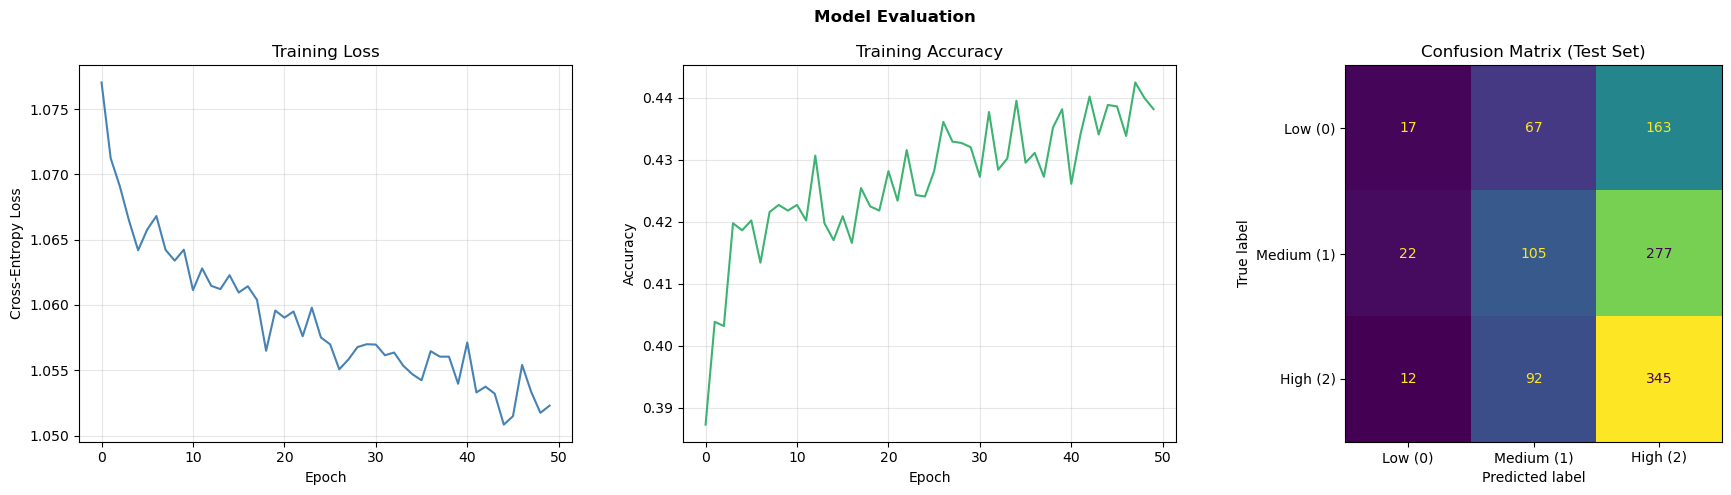

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(DEVICE))
    y_pred = logits.argmax(dim=1).cpu().numpy()

class_names = ['Low (0)', 'Medium (1)', 'High (2)']

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontweight='bold')

# Training loss
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

# Training accuracy
axes[1].plot(train_accs, color='mediumseagreen')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[2], colorbar=False)
axes[2].set_title('Confusion Matrix (Test Set)')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Model

In [13]:
# Save model weights
torch.save(model.state_dict(), 'incident_classifier.pth')
print("Model saved to incident_classifier.pth")

# Save CTGAN synthesizer
ctgan.save('ctgan_model.pkl')
print("CTGAN saved to ctgan_model.pkl")

Model saved to incident_classifier.pth
CTGAN saved to ctgan_model.pkl


## 8. Predict on New Incident

Example of how to run the trained model on a single new record.

In [14]:
def predict_severity(location, event_type, time_of_day, crowd_size, incident_type):
    """
    Predict severity of a new campus incident.

    Parameters
    ----------
    location      : str  e.g. 'Cafeteria'
    event_type    : str  e.g. 'Concert'
    time_of_day   : str  e.g. 'Night'
    crowd_size    : int  raw headcount
    incident_type : str  e.g. 'Medical'

    Returns
    -------
    dict with predicted severity label and confidence scores
    """
    row = pd.DataFrame([{
        'location': location,
        'event_type': event_type,
        'time_of_day': time_of_day,
        'crowd_size': crowd_size,
        'incident_type': incident_type
    }])

    # Encode
    for col in ['location', 'event_type', 'time_of_day', 'incident_type']:
        row[col] = encoders[col].transform(row[col])

    # Scale
    row[['crowd_size']] = scaler.transform(row[['crowd_size']])

    # Align with training columns (excluding target)
    train_cols = combined_df.drop(columns=[target]).columns
    row = row.reindex(columns=train_cols, fill_value=0).astype('float32')

    tensor = torch.tensor(row.values, dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

    pred_class = int(np.argmax(probs))
    labels = {0: 'Low', 1: 'Medium', 2: 'High'}
    return {
        'predicted_severity': labels[pred_class],
        'confidence': {labels[i]: round(float(p), 3) for i, p in enumerate(probs)}
    }


# Example prediction
result = predict_severity(
    location='Sports Complex',
    event_type='Concert',
    time_of_day='Night',
    crowd_size=450,
    incident_type='Disturbance'
)
print("Prediction:", result)

Prediction: {'predicted_severity': 'High', 'confidence': {'Low': 0.256, 'Medium': 0.282, 'High': 0.462}}


---

## Summary

| Step | Description | Output |
|------|-------------|--------|
| EDA | Visualised distributions and correlations | `eda_plots.png` |
| Preprocessing | Label encoding + StandardScaler | Encoded DataFrame |
| CTGAN | Trained on 500 real rows, generated 5,000 synthetic rows | `ctgan_model.pkl` |
| ANN | 4-layer classifier with BatchNorm + Dropout, trained for 50 epochs | `incident_classifier.pth` |
| Evaluation | Classification report + confusion matrix | `model_evaluation.png` |

### Key Design Decisions
- **`incident_type` encoded** — was string in the original notebook and caused the `numpy.object_` TypeError
- **Mini-batch training** via `DataLoader` — more stable than full-batch gradient descent
- **BatchNorm + Dropout** — reduces overfitting on the small real dataset
- **LR scheduler** — halves learning rate every 20 epochs for finer convergence
- **Stratified split** — preserves class balance in train/test sets
